In [1]:
%load_ext autoreload
%autoreload 2

# pi-metaboqc Interactive Pipeline Tutorial

This notebook provides a step-by-step interactive guide to the `pi-metaboqc` metabolomics data quality control pipeline. 

By executing each cell sequentially, you can inspect the intermediate data structures and quality assessment (QA) reports generated at each stage of the workflow.

## Step 0: Environment Setup

First, we will import the core modules of `pi-metaboqc`, configure the input data paths, and create a dedicated output directory for the results of this notebook.

In [2]:
# -------------------------------------------------------------------------
# Step 0: Environment Setup and Parameter Loading
# -------------------------------------------------------------------------
import os
import sys
import pandas as pd
from loguru import logger

import pimqc.io_utils as iu 
import pimqc.plot_utils as pu
from pimqc.dataset_builder import build_dataset
from pimqc.assessment import MetaboIntAssessor
from pimqc.filtering import MetaboIntFilter
from pimqc.correction import MetaboIntCorrector
from pimqc.imputation import MetaboIntImputer
from pimqc.normalization import MetaboIntNormalizer

logger.info("Environment initialized successfully.")

# Define standard directories
DATA_DIR = os.path.join("..", "src", "pimqc", "data")
OUTPUT_DIR = os.path.join(".", "tutorial_output")
iu._check_dir_exists(dir_path=OUTPUT_DIR, handle="makedirs")

# Load SSOT pipeline parameters
PARAMS_PATH = os.path.join(DATA_DIR, "pipeline_parameters.json")
params = iu._load_json_file(input_file_path=PARAMS_PATH)

# Load raw matrices
# meta_df = pd.read_csv(
#     os.path.join(DATA_DIR, "project_meta.csv"), header=[0])
meta_df = pd.read_csv(
    os.path.join(DATA_DIR, "project_meta_with_simu_group.csv"), header=[0])

int_df = pd.read_csv(
    os.path.join(DATA_DIR, "project_intensity.csv"), index_col=[0], header=[0])

2026-04-17 15:18:25.668 | INFO     | __main__:<module>:18 - Environment initialized successfully.


## Step 1: Dataset Construction
We will merge the raw intensity dataframe with the metadata mapping to 
build the standardized `MetaboInt` base object. This multi-indexed dataframe 
ensures analytical features and sample metadata are strictly aligned.

In [3]:
# -------------------------------------------------------------------------
# Step 1: Build Standardized Dataset
# -------------------------------------------------------------------------
step1_dir = os.path.join(OUTPUT_DIR, "01_Raw_Data")

raw_data = build_dataset(
    meta_info=meta_df,
    int_df=int_df,
    pipeline_params=params,
    mode=params.get("MetaboInt", {}).get("mode", "POS"),
    batch=params.get("MetaboInt", {}).get("batch", "Batch"),
    sample_type=params.get("MetaboInt", {}).get("sample_type", "Sample Type"),
    bio_group=params.get("MetaboInt", {}).get("bio_group", "Bio Group"),
    sample_name=params.get("MetaboInt", {}).get("sample_name", "Sample Name"),
    inject_order=params.get("MetaboInt", {}).get(
        "inject_order", "Inject Order"),
    output_dir=step1_dir
)

2026-04-17 15:18:25.851 | INFO     | pimqc.dataset_builder:build_dataset:139 - MetaboInt object saved as: .\tutorial_output\01_Raw_Data\Metabolomics_Intensity_Raw_POS.csv
2026-04-17 15:18:25.852 | INFO     | pimqc.dataset_builder:build_dataset:153 - MetaboInt object built, the shape is: (376, 466)
2026-04-17 15:18:25.853 | SUCCESS  | pimqc.io_utils:time_wrap:221 - Execution time of "build_dataset": 00:00:00.104.


## Step 2: Quality Assessment (Raw Data)
Before any mathematical transformation, we perform an initial QA to evaluate 
the baseline condition of the untargeted metabolomics data.

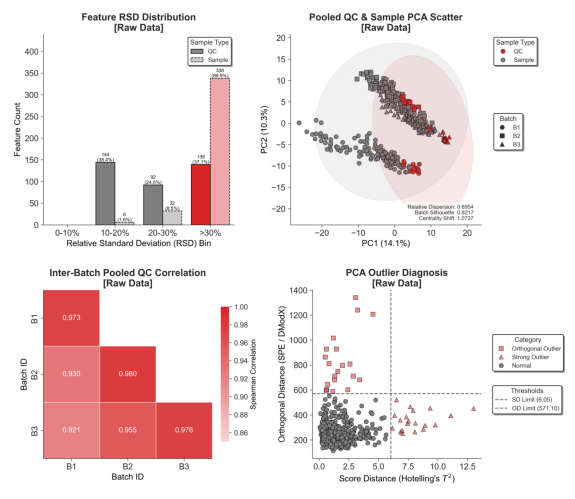

2026-04-17 15:18:32.953 | INFO     | pimqc.assessment:execute_assessment:272 - Assessor summary grid saved as: .\tutorial_output\02_QA_Raw_Data\Assessor_Grid_POS.pdf
2026-04-17 15:18:32.963 | SUCCESS  | pimqc.assessment:execute_assessment:273 - Data quality assessment completed.
2026-04-17 15:18:32.963 | SUCCESS  | pimqc.io_utils:time_wrap:221 - Execution time of "execute_assessment": 00:00:07.084.


In [4]:
# -------------------------------------------------------------------------
# Step 2: Initial QA
# -------------------------------------------------------------------------
step2_dir = os.path.join(OUTPUT_DIR, "02_QA_Raw_Data")

qa_raw = MetaboIntAssessor(data=raw_data, pipeline_params=params)
qa_raw.execute_assessment(output_dir=step2_dir)

## Step 3: High Missing Value (MV) Feature Filter (Stage 1)
We drop features containing an unacceptably high proportion of missing 
values based on the defined `mv_group_tol` biological override rule.

2026-04-17 15:18:33.002 | INFO     | pimqc.filtering:execute_mv_filtering:156 - High missing value features filter (Stage1): biological group level
2026-04-17 15:18:33.034 | INFO     | pimqc.filtering:classify_missing_types:319 - Missing Types: 312 MAR, 64 MNAR (26 Group, 38 QC).
2026-04-17 15:18:33.035 | INFO     | pimqc.filtering:classify_missing_types:327 - MNAR Preview (Top 5): ['1032', '1033', '1214', '1215', '1269']
2026-04-17 15:18:33.036 | SUCCESS  | pimqc.io_utils:time_wrap:221 - Execution time of "classify_missing_types": 00:00:00.026.
2026-04-17 15:18:33.145 | INFO     | pimqc.filtering:execute_mv_filtering:193 - Features after High-MV check: 347
2026-04-17 15:18:33.145 | INFO     | pimqc.filtering:execute_mv_filtering:194 - Data after high-missing features filtering saved as: .\tutorial_output\03_Filtered_Stage1\High-MV_Filter_Group_POS.csv


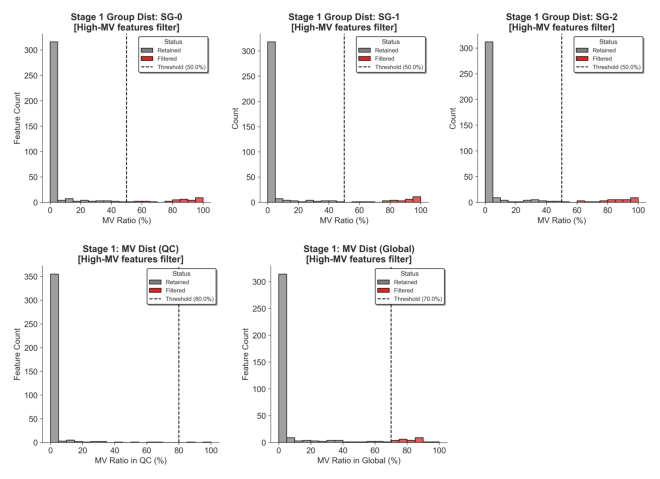

2026-04-17 15:18:36.514 | INFO     | pimqc.filtering:execute_mv_filtering:220 - High-MV features filter summary grid saved as: .\tutorial_output\03_Filtered_Stage1\MV_FLTR_Grid_POS.pdf
2026-04-17 15:18:37.788 | SUCCESS  | pimqc.filtering:execute_mv_filtering:254 - High-MV features filtering completed.
2026-04-17 15:18:37.789 | SUCCESS  | pimqc.io_utils:time_wrap:221 - Execution time of "execute_mv_filtering": 00:00:04.792.


In [5]:
# -------------------------------------------------------------------------
# Step 3: Stage 1 Filtering & Missing Mechanism Classification
# -------------------------------------------------------------------------
step3_dir = os.path.join(OUTPUT_DIR, "03_Filtered_Stage1")

fltr_stg1 = MetaboIntFilter(data=raw_data, pipeline_params=params) # type: ignore
filtered_data = fltr_stg1.execute_mv_filtering(output_dir=step3_dir)

## Step 4: Signal Drift & Batch Effect Correction
Using Quality Control (QC) samples, we build regression models (e.g., LOESS, 
Random Forest, SVR) to estimate and correct analytical signal drift 
across injection sequences.

In [6]:
# -------------------------------------------------------------------------
# Step 4: Signal Correction
# -------------------------------------------------------------------------
step4_dir = os.path.join(OUTPUT_DIR, "04_Corrected_Data")

sc_engine = MetaboIntCorrector(data=filtered_data, pipeline_params=params)
intra_data, inter_data = sc_engine.execute_signal_correction(output_dir=step4_dir)

SC [B3]: 100%|████████████████████████████████████████████| 347/347 [ETA: 00:00]
2026-04-17 15:18:50.314 | INFO     | pimqc.correction:execute_signal_correction:287 - Baseline fitting completed
2026-04-17 15:18:50.418 | INFO     | pimqc.correction:execute_signal_correction:299 - Intra-correction completed, saved as : .\tutorial_output\04_Corrected_Data\Intra_Batch_Corrected_QC-SVR_POS.csv
2026-04-17 15:18:50.419 | INFO     | pimqc.correction:execute_signal_correction:301 - MetaboInt shape after intra-correction: (347, 466)
2026-04-17 15:18:50.709 | INFO     | pimqc.correction:execute_signal_correction:322 - Inter-correction completed, saved as : .\tutorial_output\04_Corrected_Data\Inter_Batch_Corrected_QC-SVR_POS.csv
2026-04-17 15:18:50.710 | INFO     | pimqc.correction:execute_signal_correction:324 - MetaboInt shape after inter-correction: (347, 466)
2026-04-17 15:18:54.266 | SUCCESS  | pimqc.correction:execute_signal_correction:359 - Data signal drift and batch-effect correction comp

## Step 5 & 6: Quality Assessment on Corrected Data
We assess the effectiveness of the signal correction algorithms by examining 
the intra-batch and inter-batch states separately.

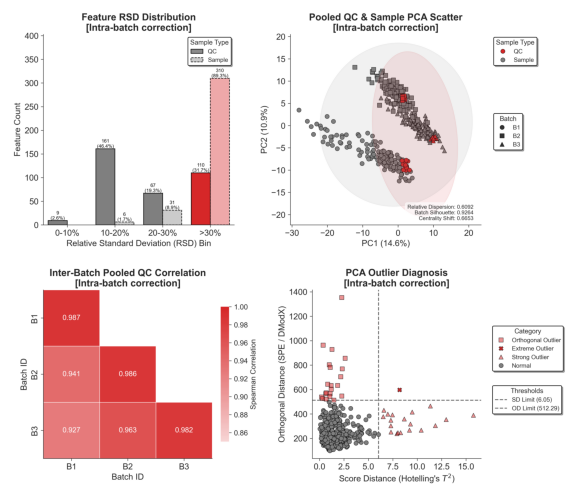

2026-04-17 15:19:01.173 | INFO     | pimqc.assessment:execute_assessment:272 - Assessor summary grid saved as: .\tutorial_output\05_QA_Intra_SC\Assessor_Grid_POS.pdf
2026-04-17 15:19:01.173 | SUCCESS  | pimqc.assessment:execute_assessment:273 - Data quality assessment completed.
2026-04-17 15:19:01.174 | SUCCESS  | pimqc.io_utils:time_wrap:221 - Execution time of "execute_assessment": 00:00:06.877.


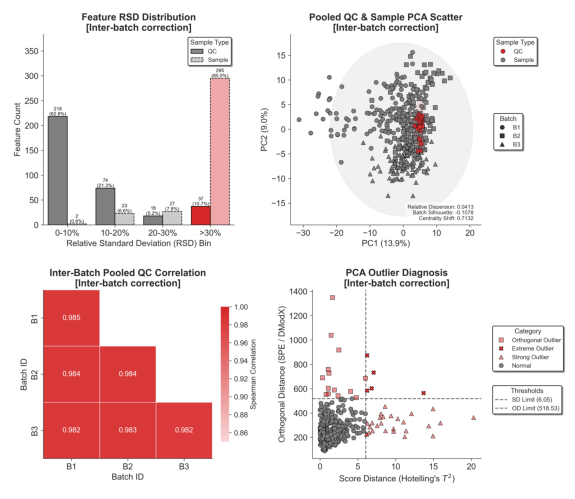

2026-04-17 15:19:08.148 | INFO     | pimqc.assessment:execute_assessment:272 - Assessor summary grid saved as: .\tutorial_output\06_QA_Inter_SC\Assessor_Grid_POS.pdf
2026-04-17 15:19:08.149 | SUCCESS  | pimqc.assessment:execute_assessment:273 - Data quality assessment completed.
2026-04-17 15:19:08.150 | SUCCESS  | pimqc.io_utils:time_wrap:221 - Execution time of "execute_assessment": 00:00:06.975.


In [7]:
# -------------------------------------------------------------------------
# Step 5 & 6: QA on Intra and Inter-batch Corrected Data
# -------------------------------------------------------------------------
step5_dir = os.path.join(OUTPUT_DIR, "05_QA_Intra_SC")

qa_intra = MetaboIntAssessor(data=intra_data, pipeline_params=params) # type: ignore
qa_intra.execute_assessment(output_dir=step5_dir)

step6_dir = os.path.join(OUTPUT_DIR, "06_QA_Inter_SC")

qa_inter = MetaboIntAssessor(data=inter_data, pipeline_params=params)
qa_inter.execute_assessment(output_dir=step6_dir)

## Step 7: Low Quality Feature Filter (Stage 2)
Features are evaluated against Blank sample ratios and QC Relative Standard 
Deviation (RSD). Missing indices are passed explicitly as current features 
default to MAR behavior prior to imputation.

2026-04-17 15:19:08.178 | INFO     | pimqc.filtering:execute_quality_filtering:370 - Features before filtering: 347
2026-04-17 15:19:08.179 | INFO     | pimqc.filtering:execute_quality_filtering:373 - Low quality features filter (Stage2): Blank/QC check.
2026-04-17 15:19:08.187 | INFO     | pimqc.filtering:execute_quality_filtering:385 - Features after Blank/QC check: 203
2026-04-17 15:19:08.188 | INFO     | pimqc.filtering:execute_quality_filtering:391 - Low quality features filter (Stage2): QC RSD check.
2026-04-17 15:19:08.197 | INFO     | pimqc.filtering:execute_quality_filtering:403 - Features after QC RSD check: 188
2026-04-17 15:19:08.257 | INFO     | pimqc.filtering:execute_quality_filtering:421 - Data after low-quality features filtering saved as: .\tutorial_output\07_Filtered_Stage2\Filtered_Data_Stage2_POS.csv


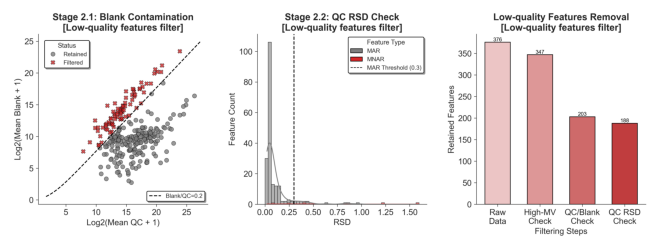

2026-04-17 15:19:09.841 | INFO     | pimqc.filtering:execute_quality_filtering:435 - Low-quality features filter summary grid saved as: .\tutorial_output\07_Filtered_Stage2\Quality_FLTR_Grid_POS.pdf
2026-04-17 15:19:10.970 | SUCCESS  | pimqc.filtering:execute_quality_filtering:453 - Low-quality features filtering completed.
2026-04-17 15:19:10.971 | SUCCESS  | pimqc.io_utils:time_wrap:221 - Execution time of "execute_quality_filtering": 00:00:02.792.


In [8]:
# -------------------------------------------------------------------------
# Step 7: Stage 2 Filtering
# --------------------------------------- ----------------------------------
step7_dir = os.path.join(OUTPUT_DIR, "07_Filtered_Stage2")

fltr_stg2 = MetaboIntFilter(data=inter_data, pipeline_params=params)
quality_filtered_data = fltr_stg2.execute_quality_filtering(output_dir=step7_dir)

## Step 8: Quality Assessment on Filtered Data

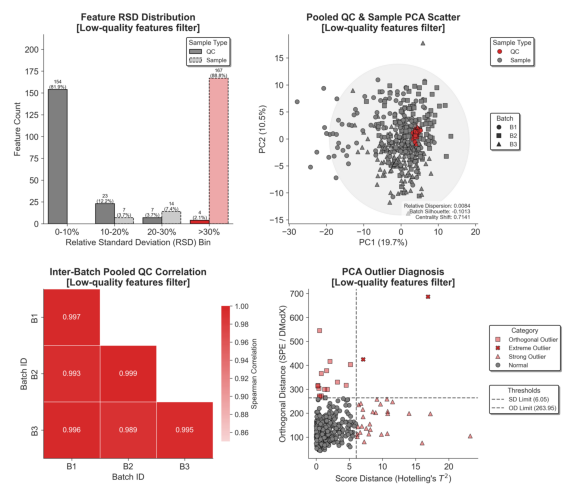

2026-04-17 15:19:18.051 | INFO     | pimqc.assessment:execute_assessment:272 - Assessor summary grid saved as: .\tutorial_output\08_QA_Filtered_Data\Assessor_Grid_POS.pdf
2026-04-17 15:19:18.052 | SUCCESS  | pimqc.assessment:execute_assessment:273 - Data quality assessment completed.
2026-04-17 15:19:18.053 | SUCCESS  | pimqc.io_utils:time_wrap:221 - Execution time of "execute_assessment": 00:00:07.053.


In [9]:
# -------------------------------------------------------------------------
# Step 8: QA Post-Filtering
# -------------------------------------------------------------------------
step8_dir = os.path.join(OUTPUT_DIR, "08_QA_Filtered_Data")

qa_fltr = MetaboIntAssessor(data=quality_filtered_data, pipeline_params=params)
qa_fltr.execute_assessment(output_dir=step8_dir)

## Step 9: Missing Value Imputation
We address remaining structural missing values using probabilistic logic, 
Random Forest, or traditional k-Nearest Neighbors (KNN).

2026-04-17 15:19:18.082 | INFO     | pimqc.imputation:select_best_algorithm:238 - Running auto-selection: Benchmarking algorithms.
2026-04-17 15:19:18.453 | INFO     | pimqc.imputation:select_best_algorithm:252 -  - [probabilistic]: Low=0.1471 | High=0.3206 | Total=0.2019
2026-04-17 15:19:18.531 | INFO     | pimqc.imputation:select_best_algorithm:252 -  - [knn          ]: Low=0.0833 | High=0.0510 | Total=0.0706
2026-04-17 15:19:18.551 | INFO     | pimqc.imputation:select_best_algorithm:252 -  - [global_min   ]: Low=0.4613 | High=0.7372 | Total=0.5257
2026-04-17 15:19:18.791 | INFO     | pimqc.imputation:select_best_algorithm:252 -  - [column_min   ]: Low=0.2569 | High=0.4802 | Total=0.3197
2026-04-17 15:19:18.791 | SUCCESS  | pimqc.imputation:select_best_algorithm:259 - Optimal method selected: 'knn'


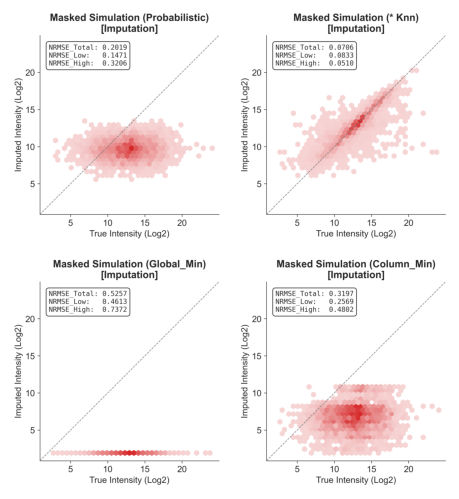

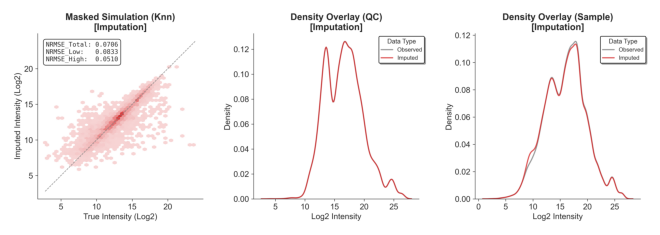

2026-04-17 15:19:25.183 | SUCCESS  | pimqc.io_utils:time_wrap:221 - Execution time of "execute_imputation": 00:00:07.102.


In [10]:
# -------------------------------------------------------------------------
# Step 9: Missing Value Imputation
# -------------------------------------------------------------------------
step9_dir = os.path.join(OUTPUT_DIR, "09_Imputation")

# 1. Initialize the imputation engine
# The engine now incorporates a biologically-aware evaluation framework
imp_engine = MetaboIntImputer(data=quality_filtered_data, pipeline_params=params)

# 2. Execute missing value imputation in 'auto' mode
# Under the hood, the engine will automatically:
#   - Generate an abundance-dependent hybrid mask (simulating both MCAR and MNAR).
#   - Benchmark multiple algorithms (probabilistic, knn, global_min, column_min).
#   - Select the optimal algorithm by minimizing 'NRMSE_Low' (prioritizing LOD fidelity).
#   - Export the fully imputed object and stratified visual grids to the disk.
imputed_data = imp_engine.execute_imputation(method="auto", output_dir=step9_dir)

## Step 10: Quality Assessment on Imputed Data

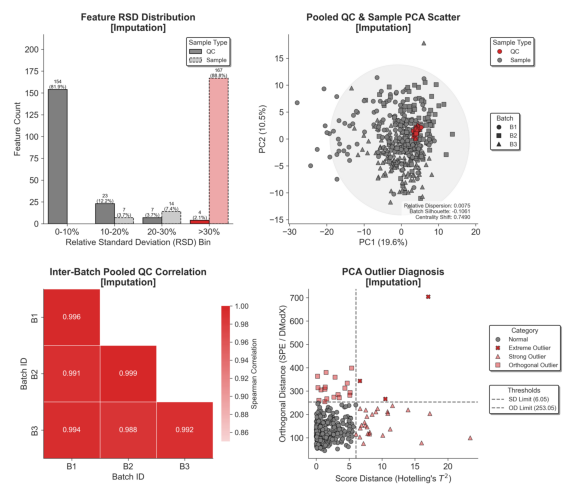

2026-04-17 15:19:32.081 | INFO     | pimqc.assessment:execute_assessment:272 - Assessor summary grid saved as: .\tutorial_output\10_QA_Imputed_Data\Assessor_Grid_POS.pdf
2026-04-17 15:19:32.081 | SUCCESS  | pimqc.assessment:execute_assessment:273 - Data quality assessment completed.
2026-04-17 15:19:32.082 | SUCCESS  | pimqc.io_utils:time_wrap:221 - Execution time of "execute_assessment": 00:00:06.871.


In [11]:
# -------------------------------------------------------------------------
# Step 10: QA Post-Imputation
# -------------------------------------------------------------------------
step10_dir = os.path.join(OUTPUT_DIR, "10_QA_Imputed_Data")

qa_imp = MetaboIntAssessor(data=imputed_data, pipeline_params=params)
qa_imp.execute_assessment(output_dir=step10_dir)

## Step 11: Data Normalization
Features are scaled and normalized (e.g., PQN, VSN) to remove remaining 
systematic bias and stabilize variance across the detection range.

2026-04-17 15:19:32.112 | INFO     | pimqc.normalization:execute_normalization:359 - Permanently dropping 24 Blank samples.
2026-04-17 15:19:32.113 | INFO     | pimqc.normalization:execute_normalization:366 - Applying Normalization | Col: PQN | Row: VSN


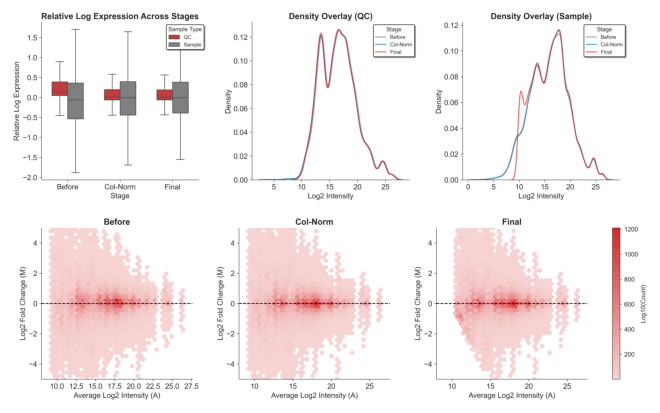

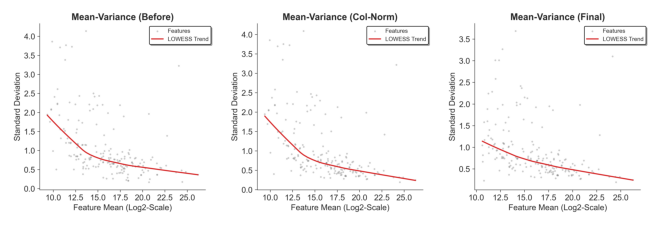

2026-04-17 15:20:04.276 | SUCCESS  | pimqc.normalization:execute_normalization:433 - Data normalization completed successfully.
2026-04-17 15:20:04.276 | SUCCESS  | pimqc.io_utils:time_wrap:221 - Execution time of "execute_normalization": 00:00:32.164.


In [12]:
# -------------------------------------------------------------------------
# Step 11: Normalization
# -------------------------------------------------------------------------
step11_dir = os.path.join(OUTPUT_DIR, "11_Normalized_Data")

# 1. Initialize normalization engine (norm_engine serves as the Raw Data)
norm_engine = MetaboIntNormalizer(imputed_data, pipeline_params=params)
# 2. Execute normalization (this automatically saves comparison PDFs to disk)
col_data, norm_data = norm_engine.execute_normalization(output_dir=step11_dir)

## Step 12 & 13: Quality Assessment on Normalized Data

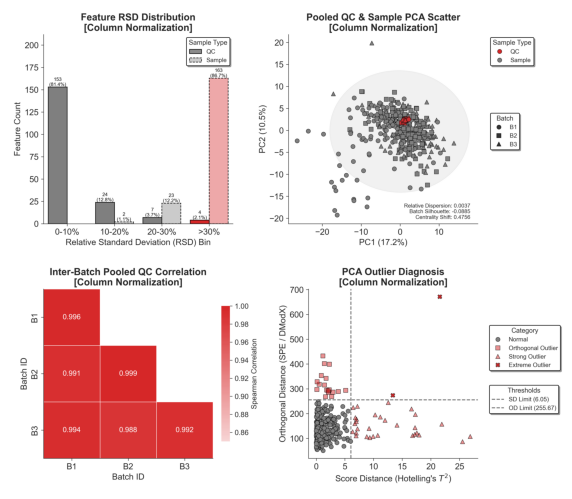

2026-04-17 15:20:11.391 | INFO     | pimqc.assessment:execute_assessment:272 - Assessor summary grid saved as: .\tutorial_output\12_QA_Column_Normalized_Data\Assessor_Grid_POS.pdf
2026-04-17 15:20:11.391 | SUCCESS  | pimqc.assessment:execute_assessment:273 - Data quality assessment completed.
2026-04-17 15:20:11.392 | SUCCESS  | pimqc.io_utils:time_wrap:221 - Execution time of "execute_assessment": 00:00:07.088.


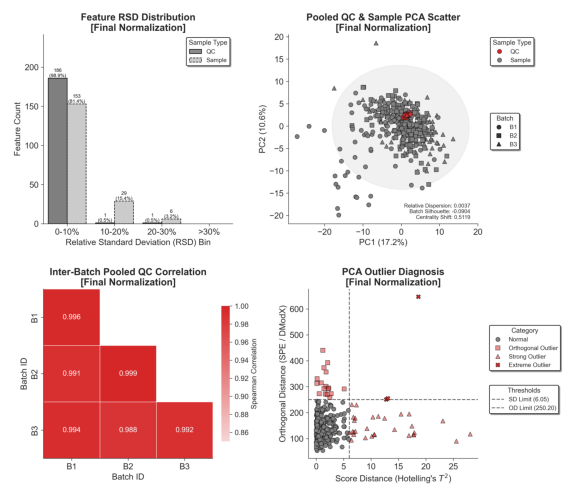

2026-04-17 15:20:18.513 | INFO     | pimqc.assessment:execute_assessment:272 - Assessor summary grid saved as: .\tutorial_output\13_QA_Final_Normalized_Data\Assessor_Grid_POS.pdf
2026-04-17 15:20:18.513 | SUCCESS  | pimqc.assessment:execute_assessment:273 - Data quality assessment completed.
2026-04-17 15:20:18.514 | SUCCESS  | pimqc.io_utils:time_wrap:221 - Execution time of "execute_assessment": 00:00:07.120.
2026-04-17 15:20:18.515 | SUCCESS  | __main__:<module>:14 - Pipeline tutorial completed successfully.


In [ ]:
# -------------------------------------------------------------------------
# Step 12: Final QA
# -------------------------------------------------------------------------
step12_dir = os.path.join(OUTPUT_DIR, "12_QA_Column_Normalized_Data")

qa_col_norm = MetaboIntAssessor(data=col_data, pipeline_params=params)
qa_col_norm.execute_assessment(output_dir=step12_dir)

step13_dir = os.path.join(OUTPUT_DIR, "13_QA_Final_Normalized_Data")

qa_col_norm = MetaboIntAssessor(data=norm_data, pipeline_params=params)
qa_col_norm.execute_assessment(output_dir=step13_dir) 

logger.success("Pipeline tutorial completed successfully.")

## Step 14: Merge Quality Assessment plots into one summary, and generate report markdown

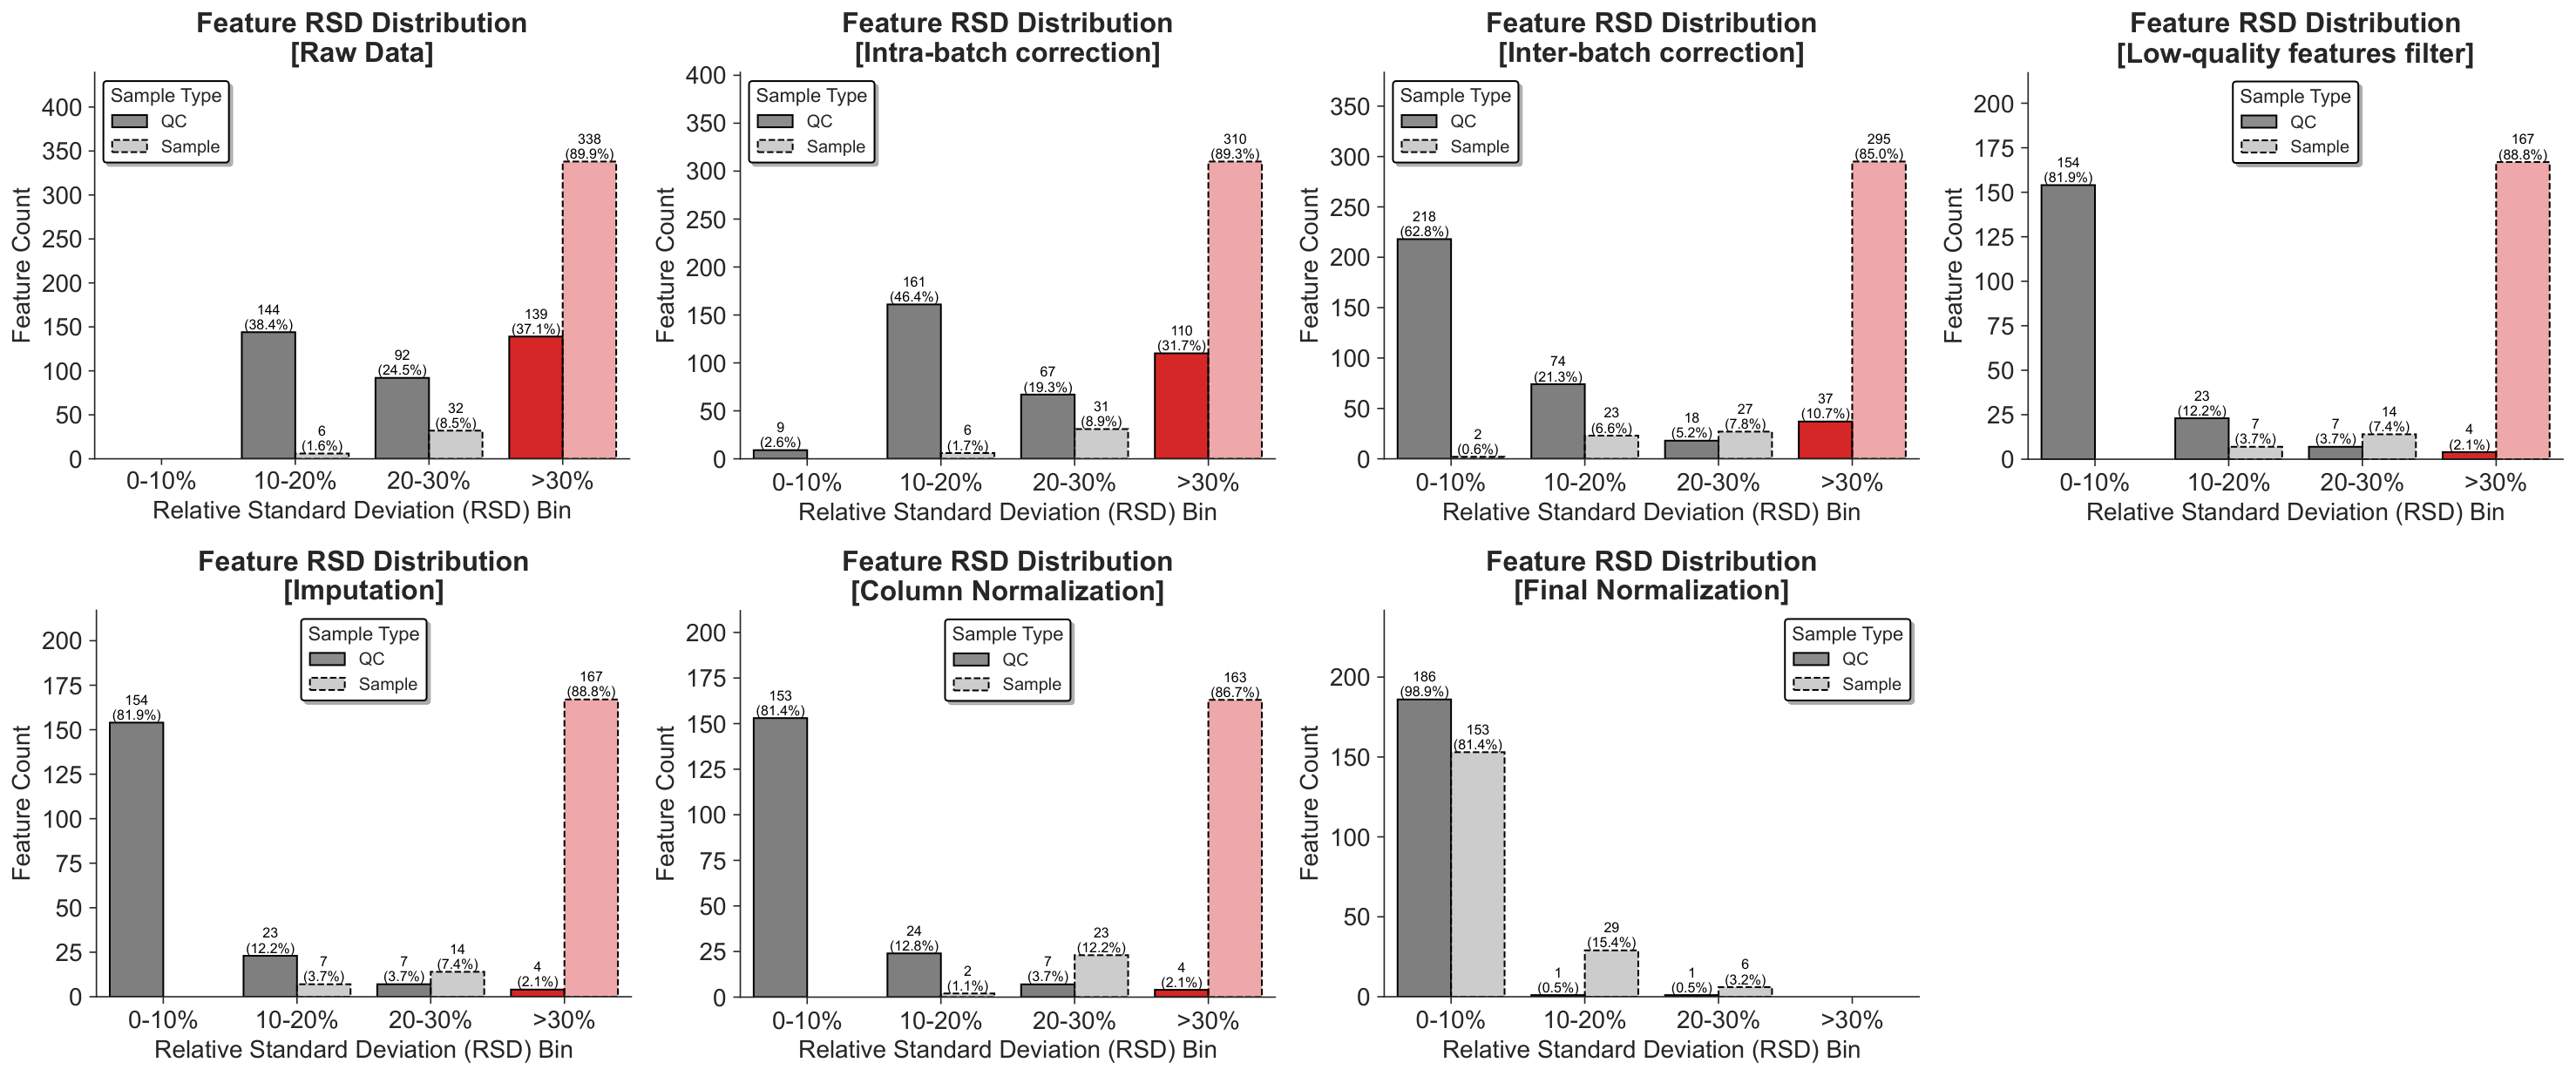

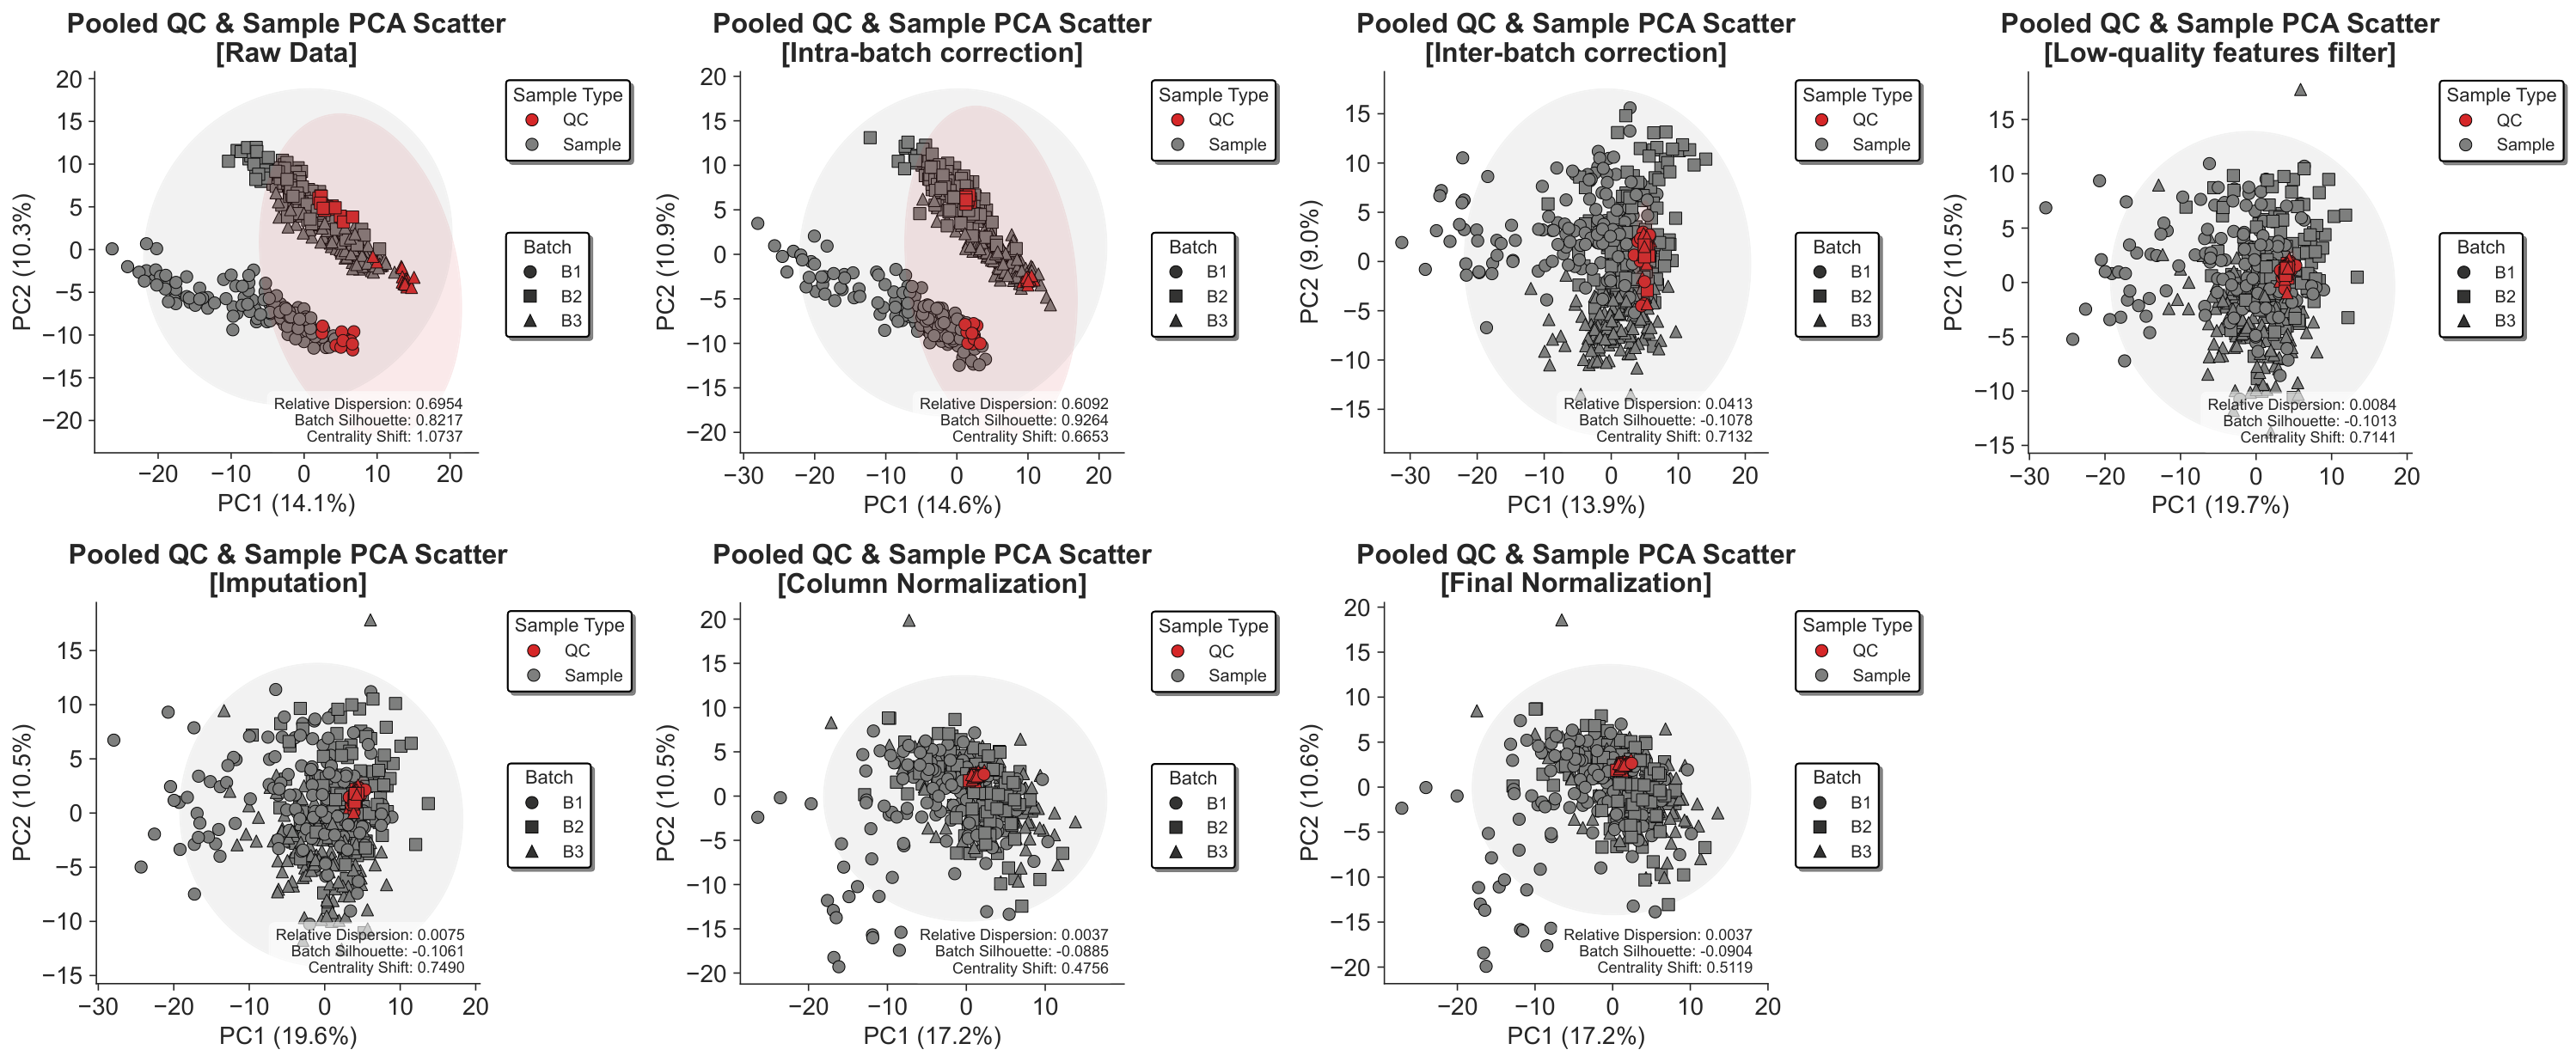

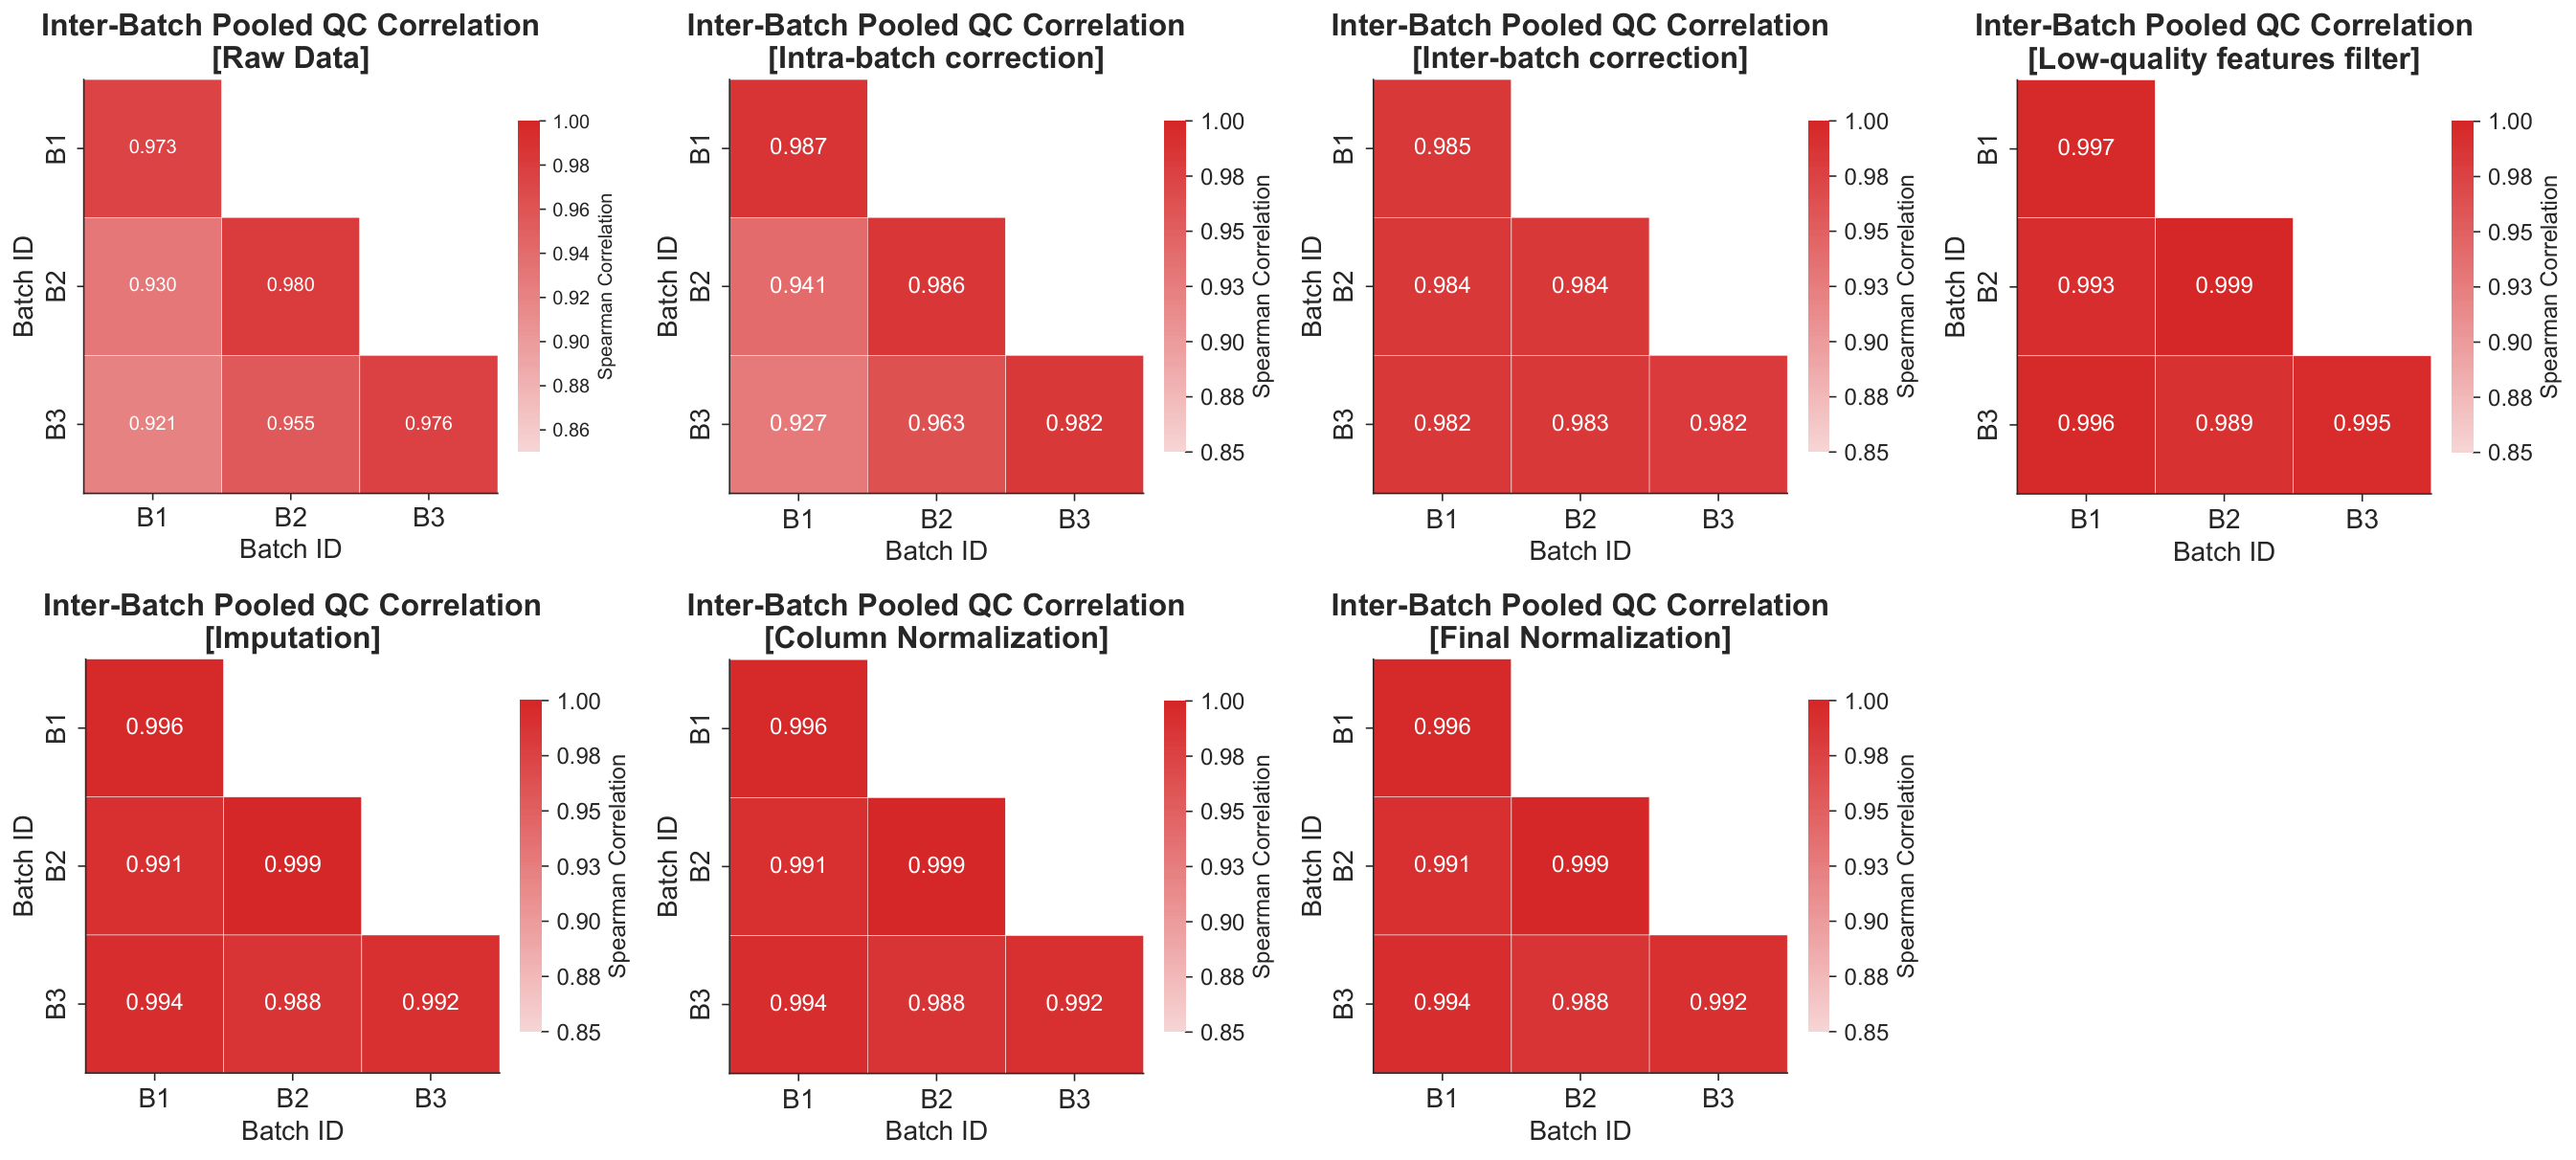

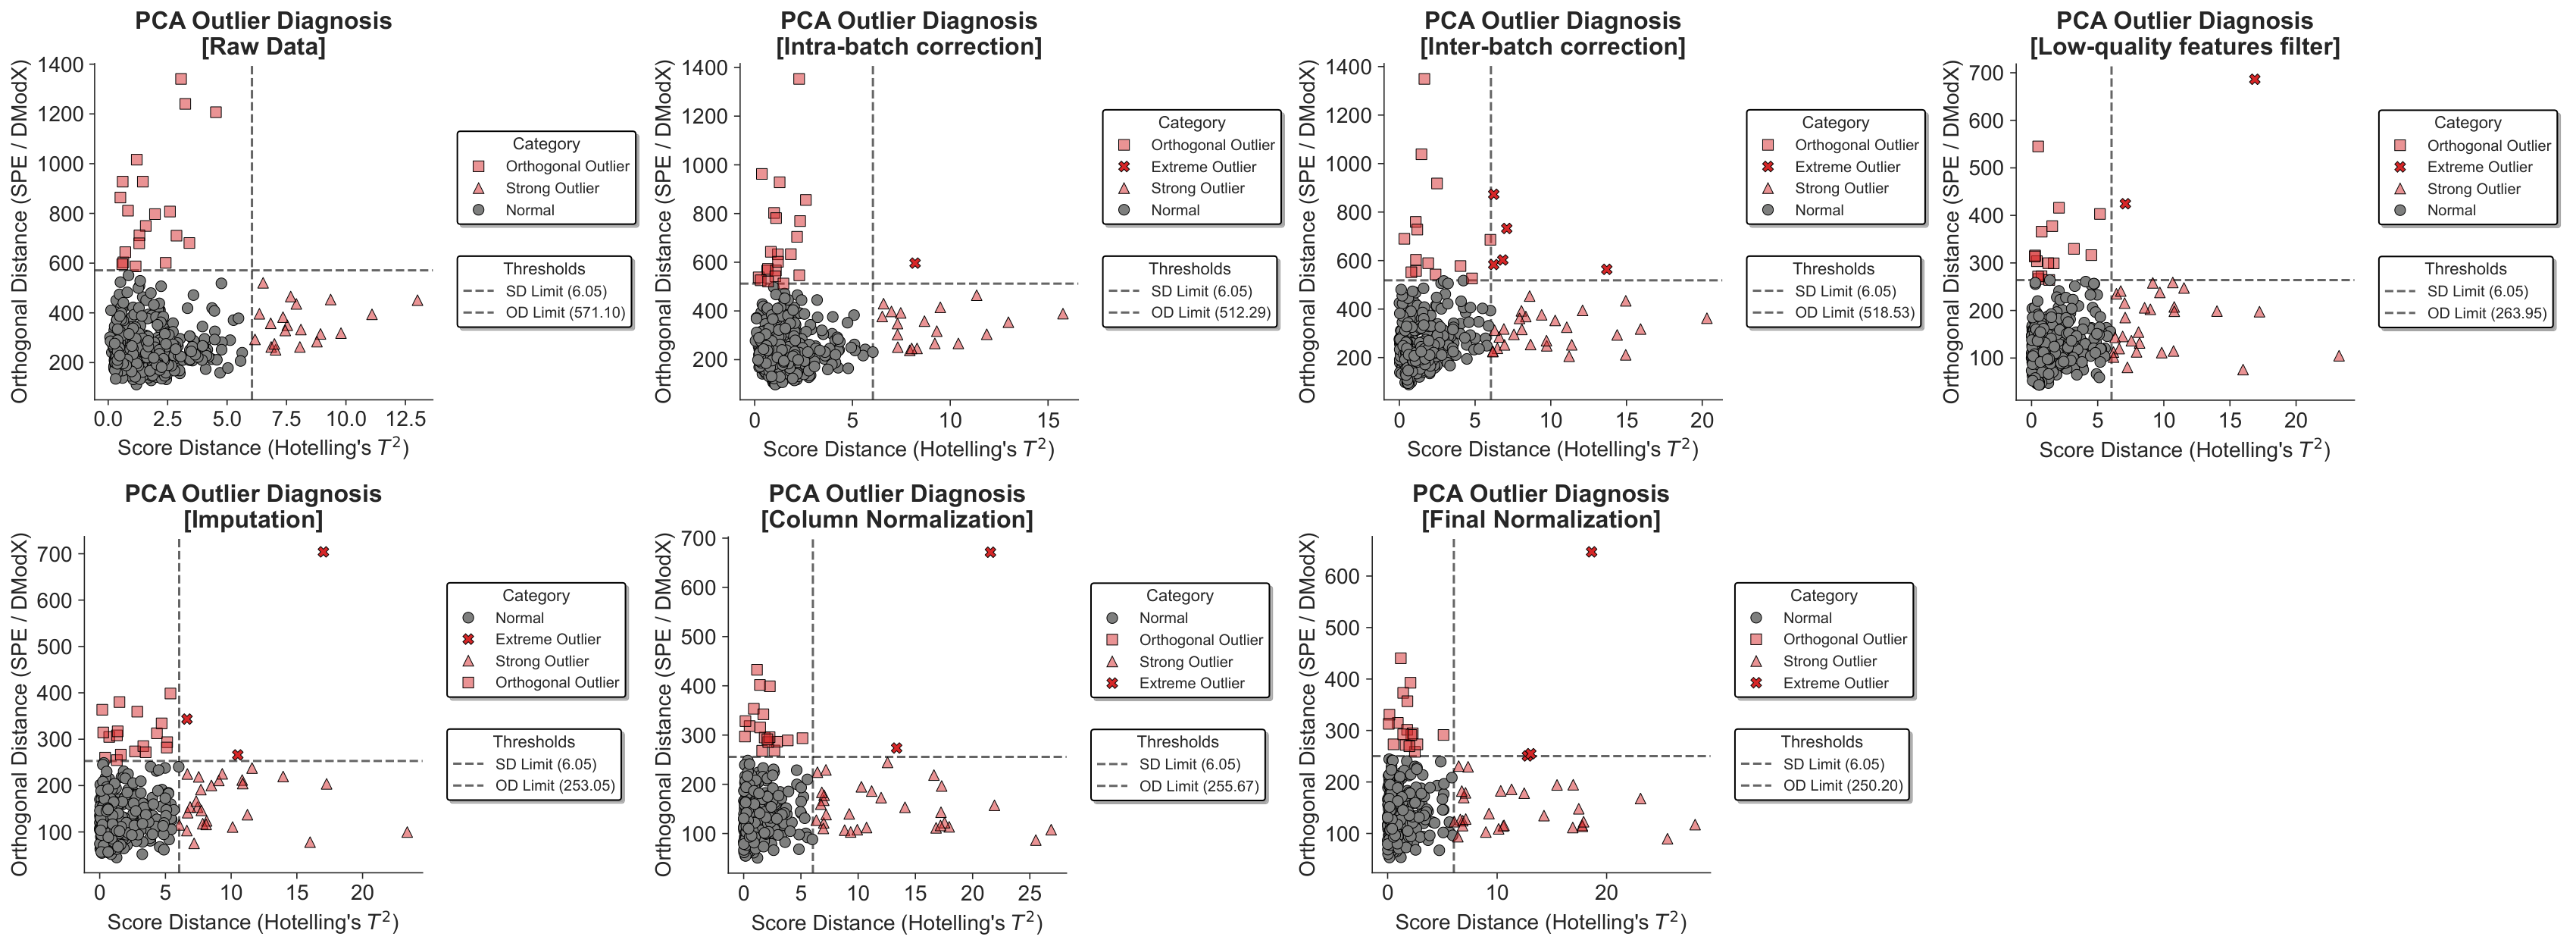

2026-04-17 15:20:20.623 | SUCCESS  | pimqc.report_utils:compile_assessor_report:212 - Report assets globally compiled at: tutorial_output\14_Report_Markdown


In [14]:
from pimqc import report_utils as ru

reporter = ru.ProjectReporter(base_dir=OUTPUT_DIR)
reporter.compile_assessor_report(cols=4, report_folder="14_Report_Markdown")